In [1]:
!pip install python-bcb

In [2]:
import pandas as pd
from bcb import sgs
pd.set_option('display.max_columns', 25)

# Obtendo os dados do SGS do Banco Central
# Dicionário com apenas as séries presentes no DataFrame
df = sgs.get({
    'IPCA': 4447,
    'IPCA_Transportes': 1639,
    'IPCA Alimentação_bebidas' : 1635,
    'INPC_Habitação':1636,
    'IPCA_Saúde_cuidados_pessoais':1641,
    'IPCA_Vestuário':1638,
    'IPCA_Educação':1643,
    'IPCA_Despesas_Pessoais':1642,
    'USDBRL': 3696,
    'Reservas Internacionais': 3546,
    'Desemprego': 24369,
    'SELIC': 4390,
    'SalMinimo': 1619,
    'PIB Mensal': 4380,
    'QteOvos': 1310,
    "INPC": 188,
    "INPC_Habitação": 1645,
    "IGP_M": 189,
    "IGP_DI": 190,
    "IPC_BR": 191,
    "Produção_Derivados_Petróleo": 1391,
    "Consumo_Gasolina": 1393,
    "Consumo_Óleo_Combustível": 1395,
    "Consumo_Energia_Comercial": 1402,
    "Consumo_Energia_Residencial": 1403,
    "Consumo_Energia_Total": 1406,
    "Estoque_Empregos_Formais_Total": 28763,
    "Estoque_Empregos_Formais_Agropecuária": 28764,
    "Estoque_Empregos_Formais_Construção": 28770,

}, start='2012-03-01', end='2024-12-30', multi=True).fillna(0)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 154 entries, 2012-03-01 to 2024-12-01
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   IPCA                                   154 non-null    float64
 1   IPCA_Transportes                       154 non-null    float64
 2   IPCA Alimentação_bebidas               154 non-null    float64
 3   INPC_Habitação                         154 non-null    float64
 4   IPCA_Saúde_cuidados_pessoais           154 non-null    float64
 5   IPCA_Vestuário                         154 non-null    float64
 6   IPCA_Educação                          154 non-null    float64
 7   IPCA_Despesas_Pessoais                 154 non-null    float64
 8   USDBRL                                 154 non-null    float64
 9   Reservas Internacionais                154 non-null    int64  
 10  Desemprego                             154 non-null    

# Tratamento de dados

=== [1] INSPEÇÃO INICIAL ===
Formato: (154, 28), Período: 2012-03-01 → 2024-12-01

Tipos (dtypes):
IPCA                                     float64
IPCA_Transportes                         float64
IPCA Alimentação_bebidas                 float64
INPC_Habitação                           float64
IPCA_Saúde_cuidados_pessoais             float64
IPCA_Vestuário                           float64
IPCA_Educação                            float64
IPCA_Despesas_Pessoais                   float64
USDBRL                                   float64
Reservas Internacionais                    int64
Desemprego                               float64
SELIC                                    float64
SalMinimo                                  int64
PIB Mensal                               float64
QteOvos                                    int64
INPC                                     float64
IGP_M                                    float64
IGP_DI                                   float64
IPC_BR             

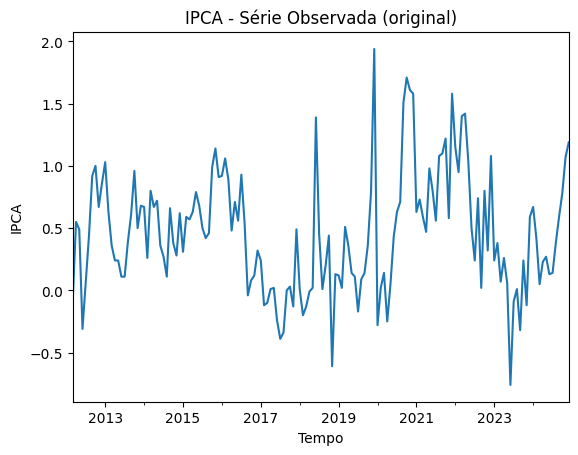


=== [2] CALENDÁRIO MENSAL CONTÍNUO ===
Datas adicionadas pelo reindex? False
Período após reindex: 2012-03-01 → 2024-12-01  (n=154)

=== [3] TIPOS E ZEROS ESTRUTURAIS → NaN ===
Tipos após ajuste de inteiros→float (para permitir NaN):
float64    28
Name: count, dtype: int64

=== [4] IMPUTAÇÃO TEMPORAL ===
Total de faltantes após imputar (time): 0

=== [5] LOG-TRANSFORM (heterocedasticidade) ===
Colunas log_ criadas: ['log_PIB Mensal', 'log_Reservas Internacionais', 'log_SalMinimo', 'log_USDBRL', 'log_Estoque_Empregos_Formais_Total', 'log_Estoque_Empregos_Formais_Agropecuária', 'log_Estoque_Empregos_Formais_Construção', 'log_Consumo_Gasolina', 'log_Consumo_Óleo_Combustível', 'log_Consumo_Energia_Comercial', 'log_Consumo_Energia_Residencial', 'log_Consumo_Energia_Total', 'log_Produção_Derivados_Petróleo', 'log_QteOvos']

=== [6] OUTLIERS (IQR) + RE-IMPUTAÇÃO ===
Top colunas com mais outliers marcados: [('IPCA_Educação', 26), ('IPCA_Saúde_cuidados_pessoais', 18), ('INPC_Habitação', 17), (

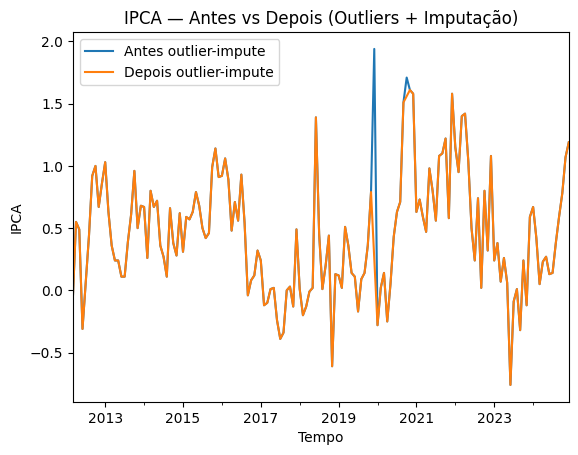


=== [7] LAGS E VARIAÇÕES % ===
Lags criadas: 30 (ex.: ['SELIC_lag1', 'SELIC_lag2', 'SELIC_lag3', 'USDBRL_lag1', 'USDBRL_lag2'])
Variações % criadas: 10 (ex.: ['pct_PIB Mensal', 'pct_USDBRL', 'pct_IGP_M', 'pct_IGP_DI', 'pct_IPC_BR'])

=== [8] SAZONALIDADE (sen/cos) ===
Colunas sazonais adicionadas: ['mes_sin', 'mes_cos']

=== [9] WARM-UP e SPLIT TEMPORAL ===
Warm-up removido: 3 mês(es)
Split 80/20 -> treino=120 | teste=31
Janela treino: 2012-06-01 → 2022-05-01
Janela teste : 2022-06-01 → 2024-12-01


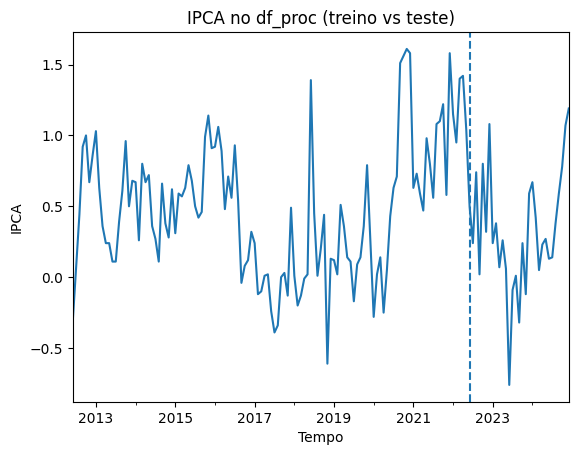


=== [10] RESUMO FINAL ===
Período original: 2012-03-01 → 2024-12-01  (n=154)
Período final   : 2012-06-01 → 2024-12-01  (n=151)
Colunas finais  : 84
Nota sobre scaler: Escalonar (StandardScaler/MinMaxScaler) APENAS no treino dentro de cada janela temporal, para evitar vazamento. Ex.: scaler.fit(X_train); X_test = scaler.transform(X_test).


In [6]:
# ================================== PRÉ-PROCESSAMENTO IPCA — PASSO A PASSO COM DIAGNÓSTICO ==================================
# Esta célula:
# 1) Valida e inspeciona o df original (índice temporal, dtypes, faltantes)
# 2) Reindexa para calendário mensal contínuo e indica se datas foram inseridas
# 3) Conserta tipos e zeros estruturais (transforma zeros "impossíveis" em NaN)
# 4) Imputa faltantes temporalmente (interp. time) para preservar dinâmica
# 5) Cria versões em log p/ séries com crescimento (reduz heterocedasticidade)
# 6) Detecta outliers via IQR -> marca como NaN -> reimputa temporalmente
# 7) Cria lags/variações % de colunas-chave; adiciona sazonalidade sen/cos
# 8) Corta "warm-up" inicial por causa de lags; cria split temporal 80/20
# 9) Mostra relatórios intermediários e gráficos simples (sem seaborn)
# =============================================================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

# -------------------------------- CONFIGURAÇÃO --------------------------------
TARGET_COL = "IPCA"

COLS_LOG_SUGERIDAS = [
    "PIB Mensal", "Reservas Internacionais", "SalMinimo", "USDBRL",
    "Estoque_Empregos_Formais_Total", "Estoque_Empregos_Formais_Agropecuária",
    "Estoque_Empregos_Formais_Construção", "Consumo_Gasolina", "Consumo_Óleo_Combustível",
    "Consumo_Energia_Comercial", "Consumo_Energia_Residencial", "Consumo_Energia_Total",
    "Produção_Derivados_Petróleo", "QteOvos"
]

LAG_COLS = [
    "SELIC", "USDBRL", "PIB Mensal", "IPCA", "INPC",
    "IGP_M", "IGP_DI", "IPC_BR", "IPCA_Transportes", "IPCA Alimentação_bebidas"
]

PCT_COLS = [
    "PIB Mensal", "USDBRL", "IGP_M", "IGP_DI", "IPC_BR",
    "Consumo_Gasolina", "Consumo_Óleo_Combustível",
    "Consumo_Energia_Comercial", "Consumo_Energia_Residencial", "Consumo_Energia_Total"
]

MAX_LAG = 3
IQR_K = 1.5
IMPUT_METHOD = "time"   # "time" (interpola no tempo) ou "ffill"
TRAIN_FRACTION = 0.8

@dataclass
class MetaPrep:
    calendario_original: pd.DatetimeIndex
    calendario_final: pd.DatetimeIndex
    reindex_incluiu_datas: bool
    colunas_log_criadas: list
    outliers_por_coluna: dict
    imputacao: str
    split_idx_train: pd.Index
    split_idx_test: pd.Index
    scaler_sugestao: str

# ------------------------------- CHECAGENS INICIAIS ----------------------------
if "df" not in globals():
    raise NameError("O DataFrame 'df' não foi encontrado no ambiente.")

if not isinstance(df.index, (pd.DatetimeIndex, pd.PeriodIndex)):
    raise TypeError("Esperado DatetimeIndex. Faça algo como: df = df.set_index(pd.to_datetime(df['data']))")

print("=== [1] INSPEÇÃO INICIAL ===")
print(f"Formato: {df.shape}, Período: {df.index.min().date()} → {df.index.max().date()}")
print("\nTipos (dtypes):")
print(df.dtypes)
print("\nFaltantes por coluna (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Gráfico rápido da série-alvo (se existir)
if TARGET_COL in df.columns:
    plt.figure()
    df[TARGET_COL].plot(title=f"{TARGET_COL} - Série Observada (original)")
    plt.xlabel("Tempo"); plt.ylabel(TARGET_COL)
    plt.show()

# --------------------------- FUNÇÕES AUXILIARES DO PIPE ------------------------
def _to_monthly_calendar(df_):
    """Garante calendário mensal contínuo (freq='MS'). Evita buracos no índice."""
    original_index = df_.index.copy()
    if isinstance(df_.index, pd.PeriodIndex):
        df_.index = df_.index.to_timestamp(how="start")
    df_ = df_.sort_index()
    full_idx = pd.date_range(start=df_.index.min(), end=df_.index.max(), freq="MS")
    reindex_incluiu_datas = len(full_idx) != len(df_.index)
    df_ = df_.reindex(full_idx)
    return df_, reindex_incluiu_datas, original_index

def _fix_dtypes_and_zeros(df_):
    """Converte ints para float (permite NaN) e troca zeros 'estruturais' por NaN (evita distorção em log/pct)."""
    df_ = df_.copy()
    for col in df_.columns:
        if pd.api.types.is_integer_dtype(df_[col]):
            df_[col] = df_[col].astype("float64")
    candidatos_zero = [c for c in df_.columns if any(k in c.lower() for k in
                    ["consumo", "estoque", "produção", "pib", "reservas", "energia", "gasolina", "óleo", "derivados"])]
    for col in candidatos_zero:
        if col in df_.columns:
            mask_zero = df_[col] == 0
            if mask_zero.sum() > 0:
                df_.loc[mask_zero, col] = np.nan
    return df_

def _impute_time(df_, method):
    """Imputação temporal: mantém a coerência da trajetória (melhor que média global)."""
    if method == "time":
        return df_.interpolate(method="time", limit_direction="both")
    elif method == "ffill":
        return df_.ffill().bfill()
    else:
        raise ValueError("IMPUT_METHOD inválido. Use 'time' ou 'ffill'.")

def _add_logs(df_, cols):
    """Cria colunas log_*, apenas onde todos os valores são positivos (log requer > 0)."""
    created = []
    df_ = df_.copy()
    for col in cols:
        if col in df_.columns:
            s = df_[col].dropna()
            if not s.empty and (s > 0).all():
                df_[f"log_{col}"] = np.log(df_[col])
                created.append(f"log_{col}")
    return df_, created

def _detect_outliers_iqr(df_, k):
    """Marca outliers (Tukey/IQR) como NaN para imputação temporal a seguir."""
    outlier_counts = {}
    df_ = df_.copy()
    for col in df_.columns:
        s = df_[col].dropna()
        if s.empty:
            outlier_counts[col] = 0
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            outlier_counts[col] = 0
            continue
        lower, upper = q1 - k * iqr, q3 + k * iqr
        mask = (df_[col] < lower) | (df_[col] > upper)
        outlier_counts[col] = int(mask.sum())
        df_.loc[mask, col] = np.nan
    return df_, outlier_counts

def _add_lags_and_pct(df_, lag_cols, max_lag, pct_cols):
    """Adiciona defasagens (lags) e variações percentuais (Δ%)."""
    df_ = df_.copy()
    for col in lag_cols:
        if col in df_.columns:
            for L in range(1, max_lag + 1):
                df_[f"{col}_lag{L}"] = df_[col].shift(L)
    for col in pct_cols:
        if col in df_.columns:
            df_[f"pct_{col}"] = df_[col].pct_change() * 100.0
    return df_

def _add_seasonality(df_):
    """Codificação sazonal suave com seno/cosseno (evita 11 dummies)."""
    df_ = df_.copy()
    month = df_.index.month
    df_["mes_sin"] = np.sin(2 * np.pi * month / 12.0)
    df_["mes_cos"] = np.cos(2 * np.pi * month / 12.0)
    return df_

def _prepare_splits(df_, frac):
    """Split temporal (sem embaralhar) para evitar vazamento de informação do futuro."""
    n = len(df_)
    split = int(n * frac)
    idx_train = df_.index[:split]
    idx_test  = df_.index[split:]
    return idx_train, idx_test

# ------------------------------ PIPELINE PASSO A PASSO --------------------------
print("\n=== [2] CALENDÁRIO MENSAL CONTÍNUO ===")
df_in = df.copy().sort_index()
df1, reindex_incluiu_datas, calendario_original = _to_monthly_calendar(df_in)
print(f"Datas adicionadas pelo reindex? {reindex_incluiu_datas}")
print(f"Período após reindex: {df1.index.min().date()} → {df1.index.max().date()}  (n={len(df1)})")

print("\n=== [3] TIPOS E ZEROS ESTRUTURAIS → NaN ===")
df2 = _fix_dtypes_and_zeros(df1)
print("Tipos após ajuste de inteiros→float (para permitir NaN):")
print(df2.dtypes.value_counts())

print("\n=== [4] IMPUTAÇÃO TEMPORAL ===")
df3 = _impute_time(df2, IMPUT_METHOD)
faltantes_pos_imput = int(df3.isna().sum().sum())
print(f"Total de faltantes após imputar ({IMPUT_METHOD}): {faltantes_pos_imput}")

print("\n=== [5] LOG-TRANSFORM (heterocedasticidade) ===")
df4, colunas_log_criadas = _add_logs(df3, COLS_LOG_SUGERIDAS)
print(f"Colunas log_ criadas: {colunas_log_criadas if colunas_log_criadas else 'Nenhuma (faltaram valores > 0 ou colunas ausentes)'}")

print("\n=== [6] OUTLIERS (IQR) + RE-IMPUTAÇÃO ===")
df5, outliers_por_coluna = _detect_outliers_iqr(df4, IQR_K)
df6 = _impute_time(df5, IMPUT_METHOD)
top_out = sorted(outliers_por_coluna.items(), key=lambda x: x[1], reverse=True)[:8]
print("Top colunas com mais outliers marcados:", top_out)

# Gráfico antes/depois (alvo) para ver suavização de outliers
if TARGET_COL in df4.columns:
    plt.figure()
    df4[TARGET_COL].plot(label="Antes outlier-impute")
    df6[TARGET_COL].plot(label="Depois outlier-impute")
    plt.title(f"{TARGET_COL} — Antes vs Depois (Outliers + Imputação)")
    plt.xlabel("Tempo"); plt.ylabel(TARGET_COL)
    plt.legend()
    plt.show()

print("\n=== [7] LAGS E VARIAÇÕES % ===")
df7 = _add_lags_and_pct(df6, LAG_COLS, MAX_LAG, PCT_COLS)
novas_lags = [c for c in df7.columns if any(c.startswith(f"{col}_lag") for col in LAG_COLS)]
novas_pct  = [c for c in df7.columns if c.startswith("pct_")]
print(f"Lags criadas: {len(novas_lags)} (ex.: {novas_lags[:5]})")
print(f"Variações % criadas: {len(novas_pct)} (ex.: {novas_pct[:5]})")

print("\n=== [8] SAZONALIDADE (sen/cos) ===")
df8 = _add_seasonality(df7)
print("Colunas sazonais adicionadas: ['mes_sin', 'mes_cos']")

print("\n=== [9] WARM-UP e SPLIT TEMPORAL ===")
warmup = MAX_LAG
df_proc = df8.iloc[warmup:].copy()
idx_train, idx_test = _prepare_splits(df_proc, TRAIN_FRACTION)
print(f"Warm-up removido: {warmup} mês(es)")
print(f"Split 80/20 -> treino={len(idx_train)} | teste={len(idx_test)}")
print(f"Janela treino: {idx_train.min().date()} → {idx_train.max().date()}")
print(f"Janela teste : {idx_test.min().date()} → {idx_test.max().date()}")

# Gráfico final do alvo no df_proc (área treino/teste)
if TARGET_COL in df_proc.columns:
    plt.figure()
    df_proc[TARGET_COL].plot(title=f"{TARGET_COL} no df_proc (treino vs teste)")
    # marca visualmente o corte
    if len(idx_test) > 0:
        plt.axvline(x=idx_test.min(), linestyle="--")
    plt.xlabel("Tempo"); plt.ylabel(TARGET_COL)
    plt.show()

# ------------------------------- META E NOTAS ----------------------------------
SCALER_NOTA = (
    "Escalonar (StandardScaler/MinMaxScaler) APENAS no treino dentro de cada janela temporal, "
    "para evitar vazamento. Ex.: scaler.fit(X_train); X_test = scaler.transform(X_test)."
)

meta = MetaPrep(
    calendario_original=calendario_original,
    calendario_final=df_proc.index,
    reindex_incluiu_datas=reindex_incluiu_datas,
    colunas_log_criadas=colunas_log_criadas,
    outliers_por_coluna=outliers_por_coluna,
    imputacao=IMPUT_METHOD,
    split_idx_train=idx_train,
    split_idx_test=idx_test,
    scaler_sugestao=SCALER_NOTA
)

print("\n=== [10] RESUMO FINAL ===")
print(f"Período original: {calendario_original.min().date()} → {calendario_original.max().date()}  (n={len(calendario_original)})")
print(f"Período final   : {df_proc.index.min().date()} → {df_proc.index.max().date()}  (n={len(df_proc)})")
print(f"Colunas finais  : {len(df_proc.columns)}")
print(f"Nota sobre scaler: {meta.scaler_sugestao}")

# Saídas úteis: df_proc (pronto p/ modelagem) e meta (logs / índices treino-teste).
# =================================================================================================================


Escalonamento a ser realizado a depender do modelo

# Treinamento

[INFO] Variáveis numéricas disponíveis em X: 83
[INFO] Treino: (120, 83) | Teste: (31, 83)

=== RESULTADOS — KNN (Instance-Based) ===
RMSE: 0.7245
MAE : 0.6268
R²  : -2.0933


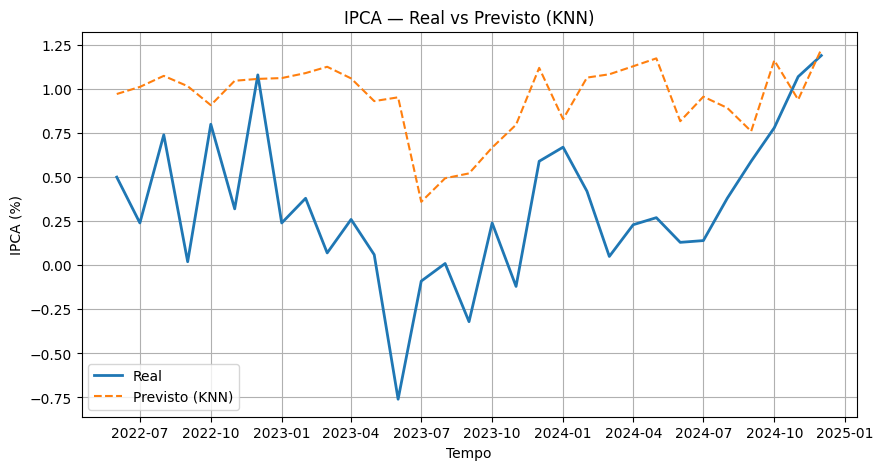

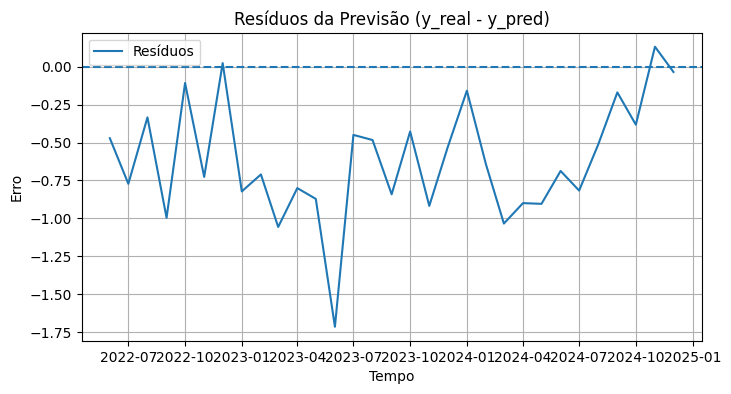


[DIAGNÓSTICO] Colunas removidas (100% NaN no treino): []
[DIAGNÓSTICO] Exemplo de contagem de NaN após imputação (deve ser 0): 0
[DIAGNÓSTICO] Todos os ±inf foram convertidos em NaN antes da imputação.


In [12]:
# ================= KNN (Instance-Based) para IPCA — com saneamento robusto e justificativas =================
# Observação: esta célula usa df_proc (gerado no seu pré-processamento) e meta (com idx_train/idx_test).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------- 1) Seleção de X e y -------------------------
TARGET_COL = "IPCA"

# X = todas as colunas numéricas exceto o alvo.
# Justificativa: KNN usa distâncias; variáveis não numéricas não são compatíveis.
X_full = df_proc.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number]).copy()
y_full = df_proc[TARGET_COL].copy()

print(f"[INFO] Variáveis numéricas disponíveis em X: {X_full.shape[1]}")

# ------------------------- 2) Split temporal (sem vazamento) -------------------------
# Justificativa: séries temporais exigem respeito à ordem temporal; não embaralhar.
idx_train = meta.split_idx_train
idx_test  = meta.split_idx_test

X_train = X_full.loc[idx_train].copy()
X_test  = X_full.loc[idx_test].copy()
y_train = y_full.loc[idx_train].copy()
y_test  = y_full.loc[idx_test].copy()

print(f"[INFO] Treino: {X_train.shape} | Teste: {X_test.shape}")

# ------------------------- 3) Sanitização: ±inf → NaN -------------------------
# Justificativa: pct_change e divisões podem gerar ±inf; o scaler não aceita.
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remoção de colunas 100% NaN no TREINO (e refletir no TESTE)
cols_all_nan_train = X_train.columns[X_train.isna().all()]
if len(cols_all_nan_train) > 0:
    print(f"[WARN] Removendo {len(cols_all_nan_train)} colunas 100% NaN no treino (e no teste): {list(cols_all_nan_train)[:8]}{'...' if len(cols_all_nan_train)>8 else ''}")
    X_train.drop(columns=cols_all_nan_train, inplace=True)
    X_test.drop(columns=cols_all_nan_train, inplace=True)

# ------------------------- 4) Imputação sem vazamento -------------------------
# Justificativa: imputar faltantes com estatística do TREINO preserva honestidade da avaliação.
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)   # fit só no treino
X_test_imp  = imputer.transform(X_test)        # aplica no teste

# ------------------------- 5) Winsorização leve (opcional, robustez) -------------------------
# Justificativa: KNN é sensível a outliers porque usa distância; clipping pelos quantis do TREINO estabiliza a geometria.
# Mantemos 1º–99º percentis como exemplo conservador; ajuste se necessário.
q_low  = np.nanpercentile(X_train_imp, 1, axis=0)
q_high = np.nanpercentile(X_train_imp, 99, axis=0)

def _clip_with_train_quantiles(X_arr, low, high):
    Xc = np.clip(X_arr, low, high)
    return Xc

X_train_imp = _clip_with_train_quantiles(X_train_imp, q_low, q_high)
X_test_imp  = _clip_with_train_quantiles(X_test_imp,  q_low, q_high)

# ------------------------- 6) Padronização (sem vazamento) -------------------------
# Justificativa: em KNN, a escala das features altera a distância; padronizar é essencial.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)  # fit no treino
X_test_scaled  = scaler.transform(X_test_imp)       # transform no teste

# ------------------------- 7) Definição do KNN e rationale de parâmetros -------------------------
# n_neighbors=7:
#   - Regra prática inicial: valores pequenos (5–15) capturam padrões locais sem superajustar a ruído.
#   - sqrt(n_treino) ~ sqrt(≈120) ≈ 11 → 7 é um ponto inicial razoável; depois, valide via TSCV.
# weights='distance':
#   - Vizinhos mais próximos (mais "parecidos") têm mais influência — faz sentido em choques/regimes econômicos.
# metric='minkowski', p=2:
#   - Distância Euclidiana padrão para dados contínuos escalonados. Alternar p=1 (Manhattan) pode ser testado em grid.
knn = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2
)

# ------------------------- 8) Treinamento -------------------------
knn.fit(X_train_scaled, y_train)

# ------------------------- 9) Previsão e avaliação -------------------------
y_pred = knn.predict(X_test_scaled)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae  = float(mean_absolute_error(y_test, y_pred))
r2   = float(r2_score(y_test, y_pred))

print("\n=== RESULTADOS — KNN (Instance-Based) ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# ------------------------- 10) Gráficos: Real vs Previsto e Resíduos -------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Real", linewidth=2)
plt.plot(y_test.index, y_pred, label="Previsto (KNN)", linestyle="--")
plt.title("IPCA — Real vs Previsto (KNN)")
plt.xlabel("Tempo"); plt.ylabel("IPCA (%)")
plt.legend(); plt.grid(True); plt.show()

residuos = y_test - y_pred
plt.figure(figsize=(8,4))
plt.plot(residuos, label="Resíduos")
plt.axhline(0, linestyle="--")
plt.title("Resíduos da Previsão (y_real - y_pred)")
plt.xlabel("Tempo"); plt.ylabel("Erro")
plt.legend(); plt.grid(True); plt.show()

# ------------------------- 11) Diagnósticos úteis -------------------------
# Quais colunas tinham NaN/inf no treino?
nans_treino = pd.Series(np.isnan(X_train_imp).sum(axis=0), index=X_train.columns)
inf_msg = "Todos os ±inf foram convertidos em NaN antes da imputação."
print("\n[DIAGNÓSTICO] Colunas removidas (100% NaN no treino):", list(cols_all_nan_train))
print("[DIAGNÓSTICO] Exemplo de contagem de NaN após imputação (deve ser 0):", int(np.isnan(X_train_imp).sum()))
print("[DIAGNÓSTICO]", inf_msg)


Por que o modelo KNN teve desempenho fraco no nosso caso

Nosso conjunto de treino tem cerca de 120 observações (mensais) mas usamos ~80 variáveis numéricas para o KNN. Isso é muito elevado para esse tipo de modelo baseado em instâncias, o que dificulta encontrar vizinhos realmente “próximos”. A teoria mostra que, em alta dimensão, distâncias perdem significado.
GeeksforGeeks
+1

O método KNN assume que dados históricos semelhantes (em termos de variáveis) geram valores de alvo semelhantes no futuro. Mas em inflação (com choques macro, políticas, câmbio, etc.), o padrão muda — isso torna difícil para o KNN “acompanhar” dados que saem da distribuição de treino.

O gráfico mostra previsão sistematicamente acima dos valores reais: indica que o modelo está “ancorado” em médias de vizinhos com inflação mais alta e não está capturando quedas ou variações para baixo — isso tende a penalizar bastante o
𝑅
2
R
2
.

Em resumo: muitos predictores, poucas observações, e mudanças de padrão fazem com que o KNN “empurre” para valores mais conservadores e tenha erro elevado.

# Salvar

In [ ]:

#salvando
df.to_csv("df_macro.csv")

# Visualizando os dados
display(df.head())

,IPCA,IPCA_Transportes,IPCA Alimentação_bebidas,INPC_Habitação,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais,USDBRL,Reservas Internacionais,Desemprego,SELIC,...,IGP_M,IGP_DI,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Consumo_Energia_Total,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Date,,,,,,,,,,,,,,,,,,,,,,,,,
2012-03-01,-0.08,0.16,0.25,0.43,0.38,-0.61,0.54,0.55,1.8221,365216,8.0,0.82,...,0.43,0.56,0.60,2169,537,59,7037,10271,38636,38754453,1470766,2910763
2012-04-01,0.55,0.10,0.51,0.73,0.96,0.98,0.04,2.23,1.8918,374272,7.8,0.71,...,0.85,1.02,0.52,2106,531,64,6856,9928,37996,39018063,1495548,2963001
2012-05-01,0.49,-0.58,0.73,0.82,0.66,0.89,-0.01,0.60,2.0223,372409,7.7,0.74,...,1.02,0.91,0.52,2136,527,61,6417,9532,36810,39213837,1549189,2989022
2012-06-01,-0.31,-1.18,0.68,0.24,0.38,0.39,0.06,0.47,2.0213,373910,7.6,0.64,...,0.66,0.69,0.11,2127,538,58,6282,9605,36528,39377064,1614204,3000347
2012-07-01,0.06,-0.03,0.91,0.51,0.36,0.04,0.12,0.91,2.0499,376154,7.5,0.68,...,1.34,1.52,0.22,2116,527,62,6033,9274,35917,39561060,1641519,3034369


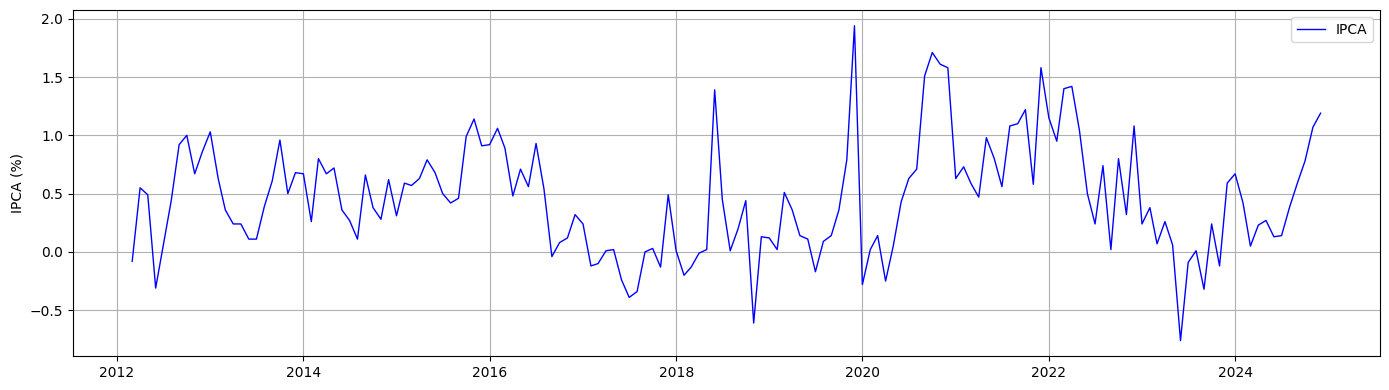

In [ ]:
import matplotlib.pyplot as plt

# Garante que o índice seja datetime (se ainda não for)
df.index = pd.to_datetime(df.index)

# Cria o gráfico no estilo que você mostrou
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['IPCA'], color='blue', linewidth=1, label='IPCA')

plt.ylabel('IPCA (%)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()
